# State Estimation with Physics-Encoded Neural Network 

Using a Context-Aware DeLaN model with log-Cholesky decomposition for inertia matrix and torque biases estimation, and residual torque prediction. Use inertia matrix and torque biases in Kalman Filter for state estimation.

Currently working with simulated data by `mpx`.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")  # GPU nicht komplett reservieren
# os.environ["JAX_PLATFORMS"] = "cpu"                            # einkommentieren, falls die GPU belegt ist

from pathlib import Path

seeds = range(5)

dataset_num = 8
dataset_path = Path.cwd().parent / f"custom_datasets/quad_mass_dataset_run{dataset_num}.npz"

# Alle 10 Checkpoints (2 Input-Varianten x 5 Seeds) liegen im felan-Repo;
# mpx/trained_models enthaelt nur die seed_0-Kopien.
felan_model_dir = Path.cwd().parent.parent / "felan/felan/trained_models/aliengo/LogChol-CaDeLaC"
name_template = ("epochs_1000_quad_mass_dataset_run8_input_values_{input_values}"
                 "_16-16_lstm5x10_wd1e-05_span0.5s-stride4-gap10_seed_{seed}")

fig_dir = Path("figures/report_part2")
fig_dir.mkdir(parents=True, exist_ok=True)

### Evaluate Input Data / Model

The input data for the LSTM could be either [joint_pos, joint_vel, tau_diff] or [base_orient, base_lin_vel, base_ang_vel, base_pos_z, tau_diff]. 

Evaluate performance of both options across all seeds. Log all data to use in a table in the report, determine best model.

**Was die Metriken bewerten** — Modellebene, *offline*: reiner Forward-Pass auf dem Testsatz, History aus geloggten Ground-Truth-Kanälen. Das isoliert die Modellgüte von der Filterintegration.

| Metrik | Was sie misst | Referenz |
|---|---|---|
| **τ̃-MSE** | Vorhersage des Residualdrehmoments, normiert wie das Trainingsziel (pro Kanal durch Var(τ̃)+1e-2 geteilt, sonst dominiert f_z alles) | Nominalmodell = „Residuum 0 vorhersagen" |
| **Bias-MSE** | Vorhersage des Bias-Residuums b̃ gegen Δc+Δg — die Größe, die der KF auf `qfrc_bias` addiert. Berechnet als Forward-Pass bei q̈=0 (Euler-Lagrange: τ(q̈=0) = Bias) | Nominalmodell |
| **Masse-MAE** | Zusatzmasse M̃[0,0], Laufmittel gegen geloggtes `base_mass` — die Größe, die der KF auf die Inertiamatrix addiert | physikalische Fensterschranke `mean(τ̃_z)/g`, gleich aggregiert |

**Achtung:** Offline entscheidet die Varianten-Frage *nicht* — im Betrieb bezieht die base-Variante ihre Features (base_vel, p_z) aus dem Filter selbst (Rückkopplung + Train/Deploy-Verteilungsshift). Darum folgt nach der Tabelle eine Online-Gegenprobe mit dem Modell **im** Filter.

In [2]:
# Offline-Vergleich aller 10 Modelle (JIT-Forward-Pass pro Modell, Ergebnisse gecacht).
# Hinweis: evaluate_dataset waere hier das falsche Werkzeug -- 10 Modelle x 50 Filterlaeufe,
# und es mischt Modellguete mit Filterintegration. Die kommt gezielt in der naechsten Zelle.
from utils.model_comparison import compare_input_variants, print_comparison

rows, refs = compare_input_variants(
    dataset_path, felan_model_dir, name_template, seeds=seeds,
    variants=("joint", "base_pos_z"),
    cache_file=fig_dir / "model_comparison_cache.json")

best_offline = print_comparison(rows, refs)


Variante     Seed   tau-MSE  Bias-MSE  Masse-MAE  Masse-RMSE
------------------------------------------------------------
joint           0     0.163     0.070      0.138       0.260
joint           1     0.231     0.147      0.171       0.302
joint           2     0.191     0.095      0.170       0.268
joint           3     0.199     0.099      0.124       0.229
joint           4     0.191     0.061      0.138       0.241
base_pos_z      0     0.243     0.136      0.164       0.296
base_pos_z      1     0.167     0.062      0.140       0.253
base_pos_z      2     0.198     0.053      0.137       0.245
base_pos_z      3     0.196     0.051      0.122       0.233
base_pos_z      4     0.173     0.068      0.148       0.254
------------------------------------------------------------
joint        tau-MSE      0.195 +- 0.022   [0.163, 0.231]
joint        Bias-MSE     0.094 +- 0.030   [0.061, 0.147]
joint        Masse-MAE    0.148 +- 0.019   [0.124, 0.171]
--------------------------------

In [3]:
# Online-Gegenprobe: bester Offline-Seed jeder Variante, Modell laeuft IM Filter
# (online-realistisch, keine GT-Kanaele), nur die 12 Testlaeufe.
# Der Massenfehler online (dm_last = eingeschwungenes Laufmittel) entscheidet die Variante.
import numpy as np
from utils.evaluate import evaluate_dataset

test_runs = [0, 1, 3, 8, 11, 13, 20, 25, 31, 33, 39, 45]   # Testsplit (seed 0)

online = {}
for variant in ("joint", "base_pos_z"):
    cand = min((r for r in rows if r["input_values"] == variant), key=lambda r: r["mass_mae"])
    res = evaluate_dataset(dataset_path, felan_model_dir / cand["model"],
                           sim_nums=test_runs, verbose=False)
    mae = float(np.mean([abs(r["inertia"]["dm_err"]) for r in res["runs"] if r["has_model"]]))
    vel_z = float(np.mean([r["kf"]["vel_rmse"][2] for r in res["runs"]]))
    online[variant] = {"model": cand["model"], "offline": cand["mass_mae"],
                       "online": mae, "vel_z": vel_z}
    print(f"{variant:<12} Masse-MAE offline {cand['mass_mae']:.3f} kg -> online {mae:.3f} kg"
          f"   (KF vel_z {vel_z:.3f} m/s, {cand['model'].rsplit('_', 1)[-1]})")

best_variant = min(online, key=lambda v: online[v]["online"])
best_model_name = online[best_variant]["model"]
print(f"\nGewaehlte Variante: {best_variant}  ->  {best_model_name}")

Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_

In [4]:
# Vergleich der vorhergesagten Residuen fuer das gewaehlte Modell, pro Freiheitsgrad
# (offline, unnormierte RMSE in N bzw. Nm). "Verb." = Verbesserung gegenueber dem
# Nominalmodell (Residuum 0); negativ = Netzkorrektur schadet in diesem Kanal.
best_row = next(r for r in rows if r["model"] == best_model_name)

lbl = ["f_x [N]", "f_y [N]", "f_z [N]", "tau_roll [Nm]", "tau_pitch [Nm]", "tau_yaw [Nm]"]
tau_rmse = np.array(best_row["tau_rmse_per_dof"])
tau_nom = np.array(best_row["tau_rmse_nominal_per_dof"])
bias_rmse = np.array(best_row["bias_rmse_per_dof"])

print(f"Residuen-Vorhersage {best_model_name.rsplit('values_', 1)[-1]} (Testsatz, offline)\n")
print(f"{'Kanal':<15}{'tau~ RMSE':>11}{'Nominal':>10}{'Verb.':>8}{'b~ RMSE':>10}")
for i in range(6):
    impr = 100 * (1 - tau_rmse[i] / tau_nom[i])
    print(f"{lbl[i]:<15}{tau_rmse[i]:>11.3f}{tau_nom[i]:>10.3f}{impr:>7.0f}%{bias_rmse[i]:>10.3f}")

print("\nMassenfehler pro Testlauf [kg]:")
for run_lbl, e in zip(best_row["test_labels"], best_row["mass_err_per_run"]):
    print(f"  {run_lbl:<8} {e:+.3f}")

Residuen-Vorhersage joint_16-16_lstm5x10_wd1e-05_span0.5s-stride4-gap10_seed_3 (Testsatz, offline)

Kanal            tau~ RMSE   Nominal   Verb.   b~ RMSE
f_x [N]              0.214     2.226     90%     0.003
f_y [N]              0.226     2.393     91%     0.006
f_z [N]              2.679    30.352     91%     2.592
tau_roll [Nm]        0.279     1.704     84%     0.203
tau_pitch [Nm]       0.332     2.445     86%     0.250
tau_yaw [Nm]         0.062     0.244     75%     0.010

Massenfehler pro Testlauf [kg]:
  run_0    +0.037
  run_1    +0.026
  run_3    +0.008
  run_8    -0.013
  run_11   +0.549
  run_13   +0.550
  run_20   +0.011
  run_25   +0.020
  run_31   +0.092
  run_33   +0.067
  run_39   +0.093
  run_45   -0.023


### Evaluate KF estimation

The state estimation is tested with these methods:

1. Leg odometry alone
2. KF with nominal model (use only torque, inertia matrix, qfrc_bias for without payload)
3. KF with LogChol-CaDeLaC (proposed approach)
4. KF with gt residual model (ground truth values from simulation)

For each state parameter, plot the estimation for each method, along with the ground truth.

**Verifiziert, dass der Code genau das macht:** `run_ladder_for_sim` baut ein gemeinsames Argument-Dict (identisches Q, R, `est_mode 4`, gleiche Filterstruktur) und ruft damit alle drei Filtervarianten auf — nominal (`cadelac_path=None`), CaDeLaC, oracle (`oracle_M_res` = Δm·I₃ aus geloggtem `base_mass`, `oracle_qfrc_res` = geloggtes Δc+Δg). Keine GT-Kanäle an den Filter (online-realistisch). Die Leg-Odometrie wird nicht separat gerechnet — sie ist die rohe Messung `leg_odom_vel`, die in jedem Ergebnis identisch mitgeloggt wird.

`plot_state_comparison` erzeugt pro Zustandsparameter eine Figur: **lin. Geschwindigkeit** (5 Kurven: GT + Leg-Odom + 3 Filter), **Winkelgeschwindigkeit**, **Position** (je 4 Kurven: GT + 3 Filter — die Leg-Odometrie misst nur Geschwindigkeit, Gl. `leg_odom_measurement`, und liefert weder Winkelgeschwindigkeit noch Position) und **Kontaktkräfte** (4 Beine × 3 Komponenten, mit RMSE pro Methode im Titel).

In [5]:
from utils.kf_utils import load_custom_dataset
from utils.report_plots import run_ladder_for_sim

# Bestes Modell aus der Online-Gegenprobe (best_model_name aus der Zelle oben)
cadelac_path = felan_model_dir / best_model_name

# Repraesentativer TESTLAUF fuer die Zeitreihen-Plots (Payload 4.64 kg, groesstes
# Residuum -> Unterschiede am sichtbarsten). Andere Testlaeufe: siehe test_runs.
sim_num = 45
data = load_custom_dataset(dataset_path=dataset_path, sim_num=sim_num)

ladder = run_ladder_for_sim(data, cadelac_path)   # nominal, cadelac, oracle -- identisches Q/R
print(f"Varianten gerechnet: {sorted(ladder.keys())}  |  Payload: {data['base_mass'][0] - 13.042:.3f} kg")

Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Varianten gerechnet: ['cadelac', 'nominal', 'oracle']  |  Payload: 4.637 kg


Methode            vel x   vel y   vel z   ang vel (Mittel)
Leg-Odom           0.061   0.026   0.101                  -
nominal            0.038   0.039   0.214              0.050
cadelac            0.033   0.014   0.384              0.038
oracle             0.030   0.020   0.370              0.041


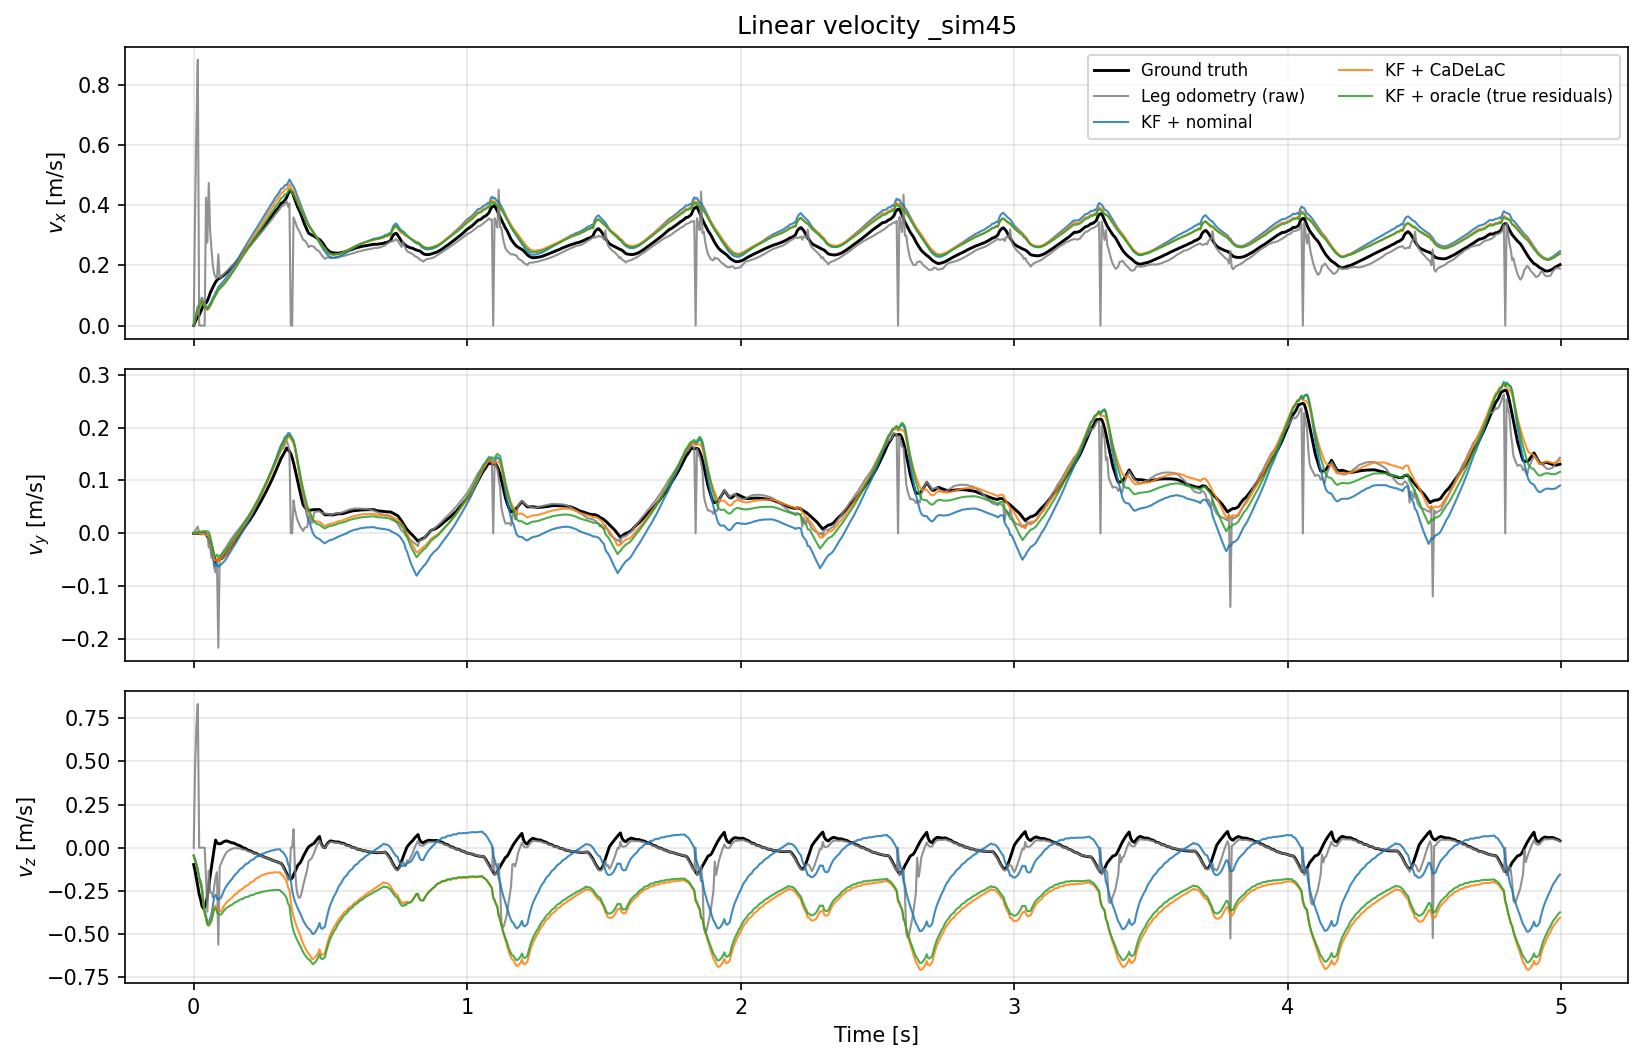

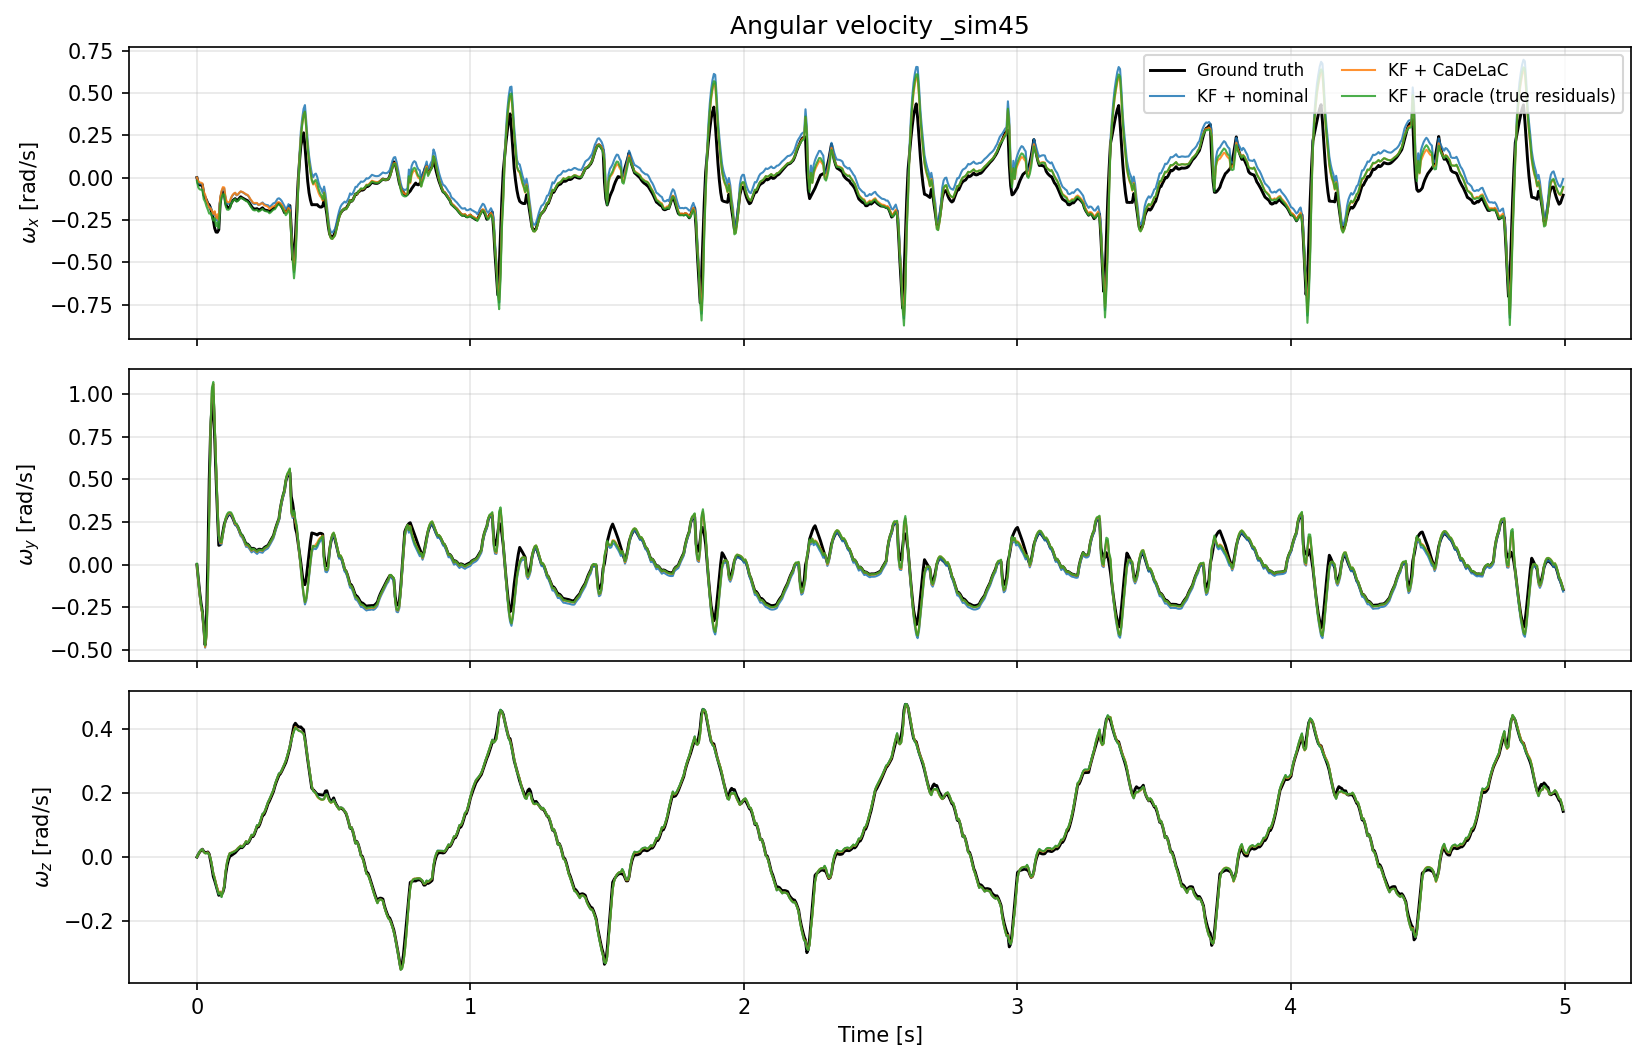

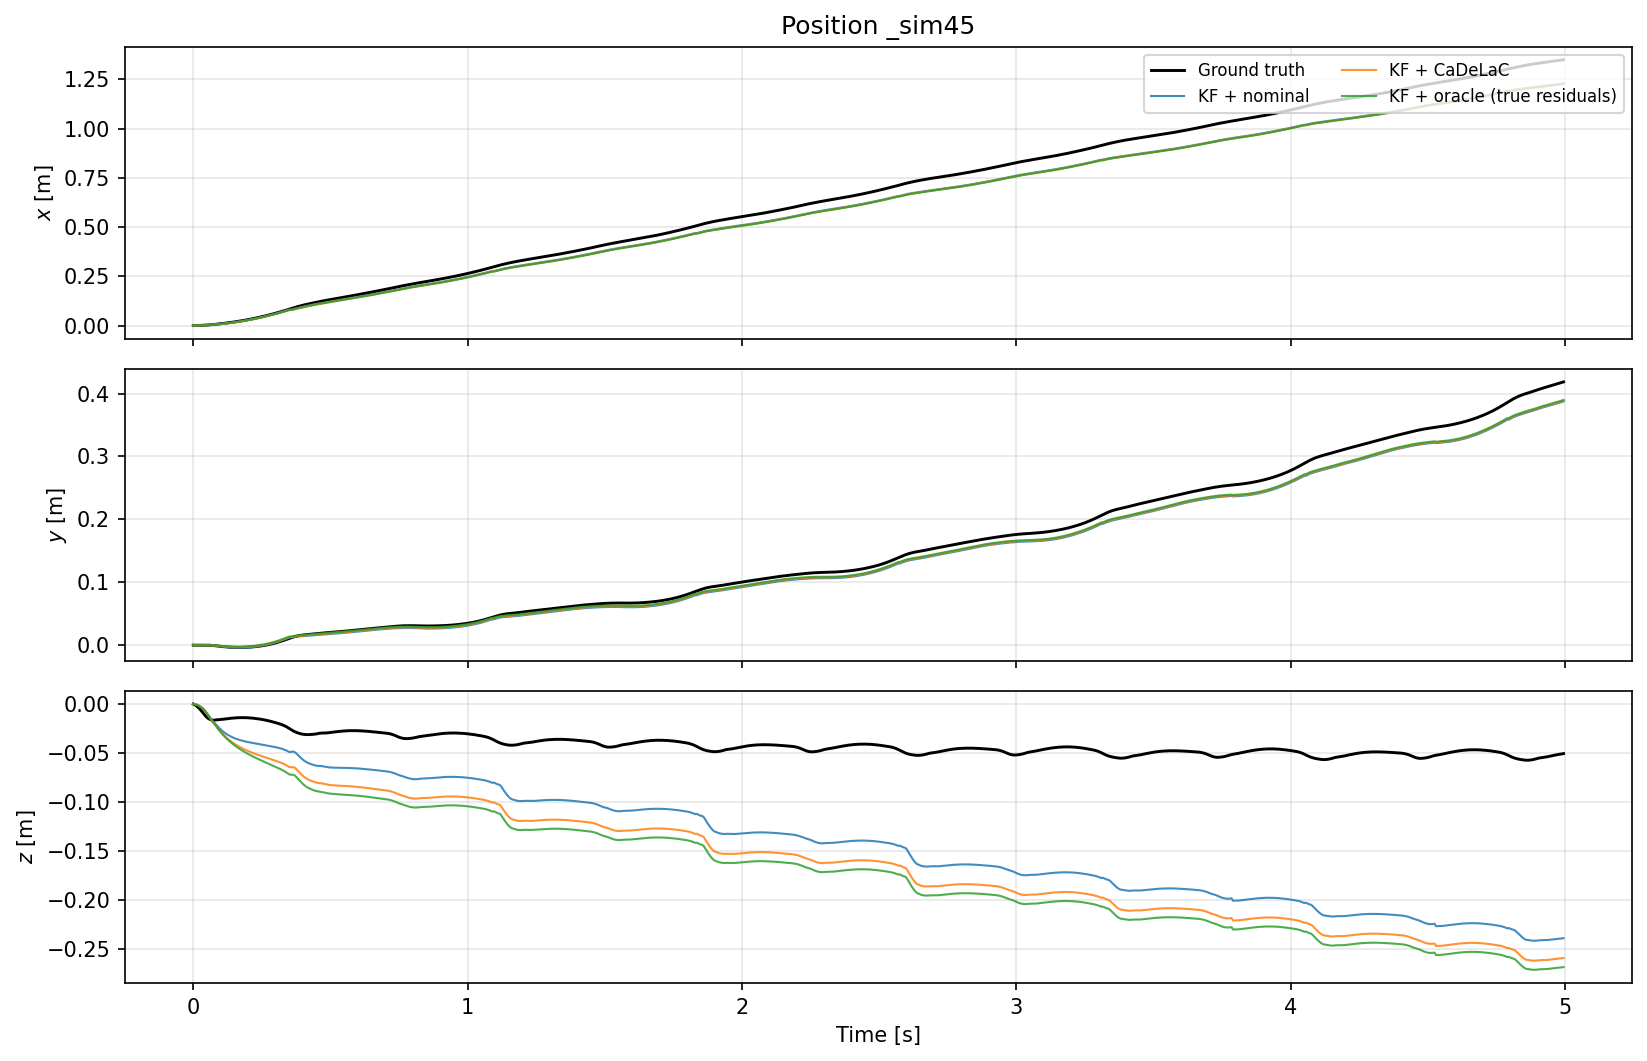

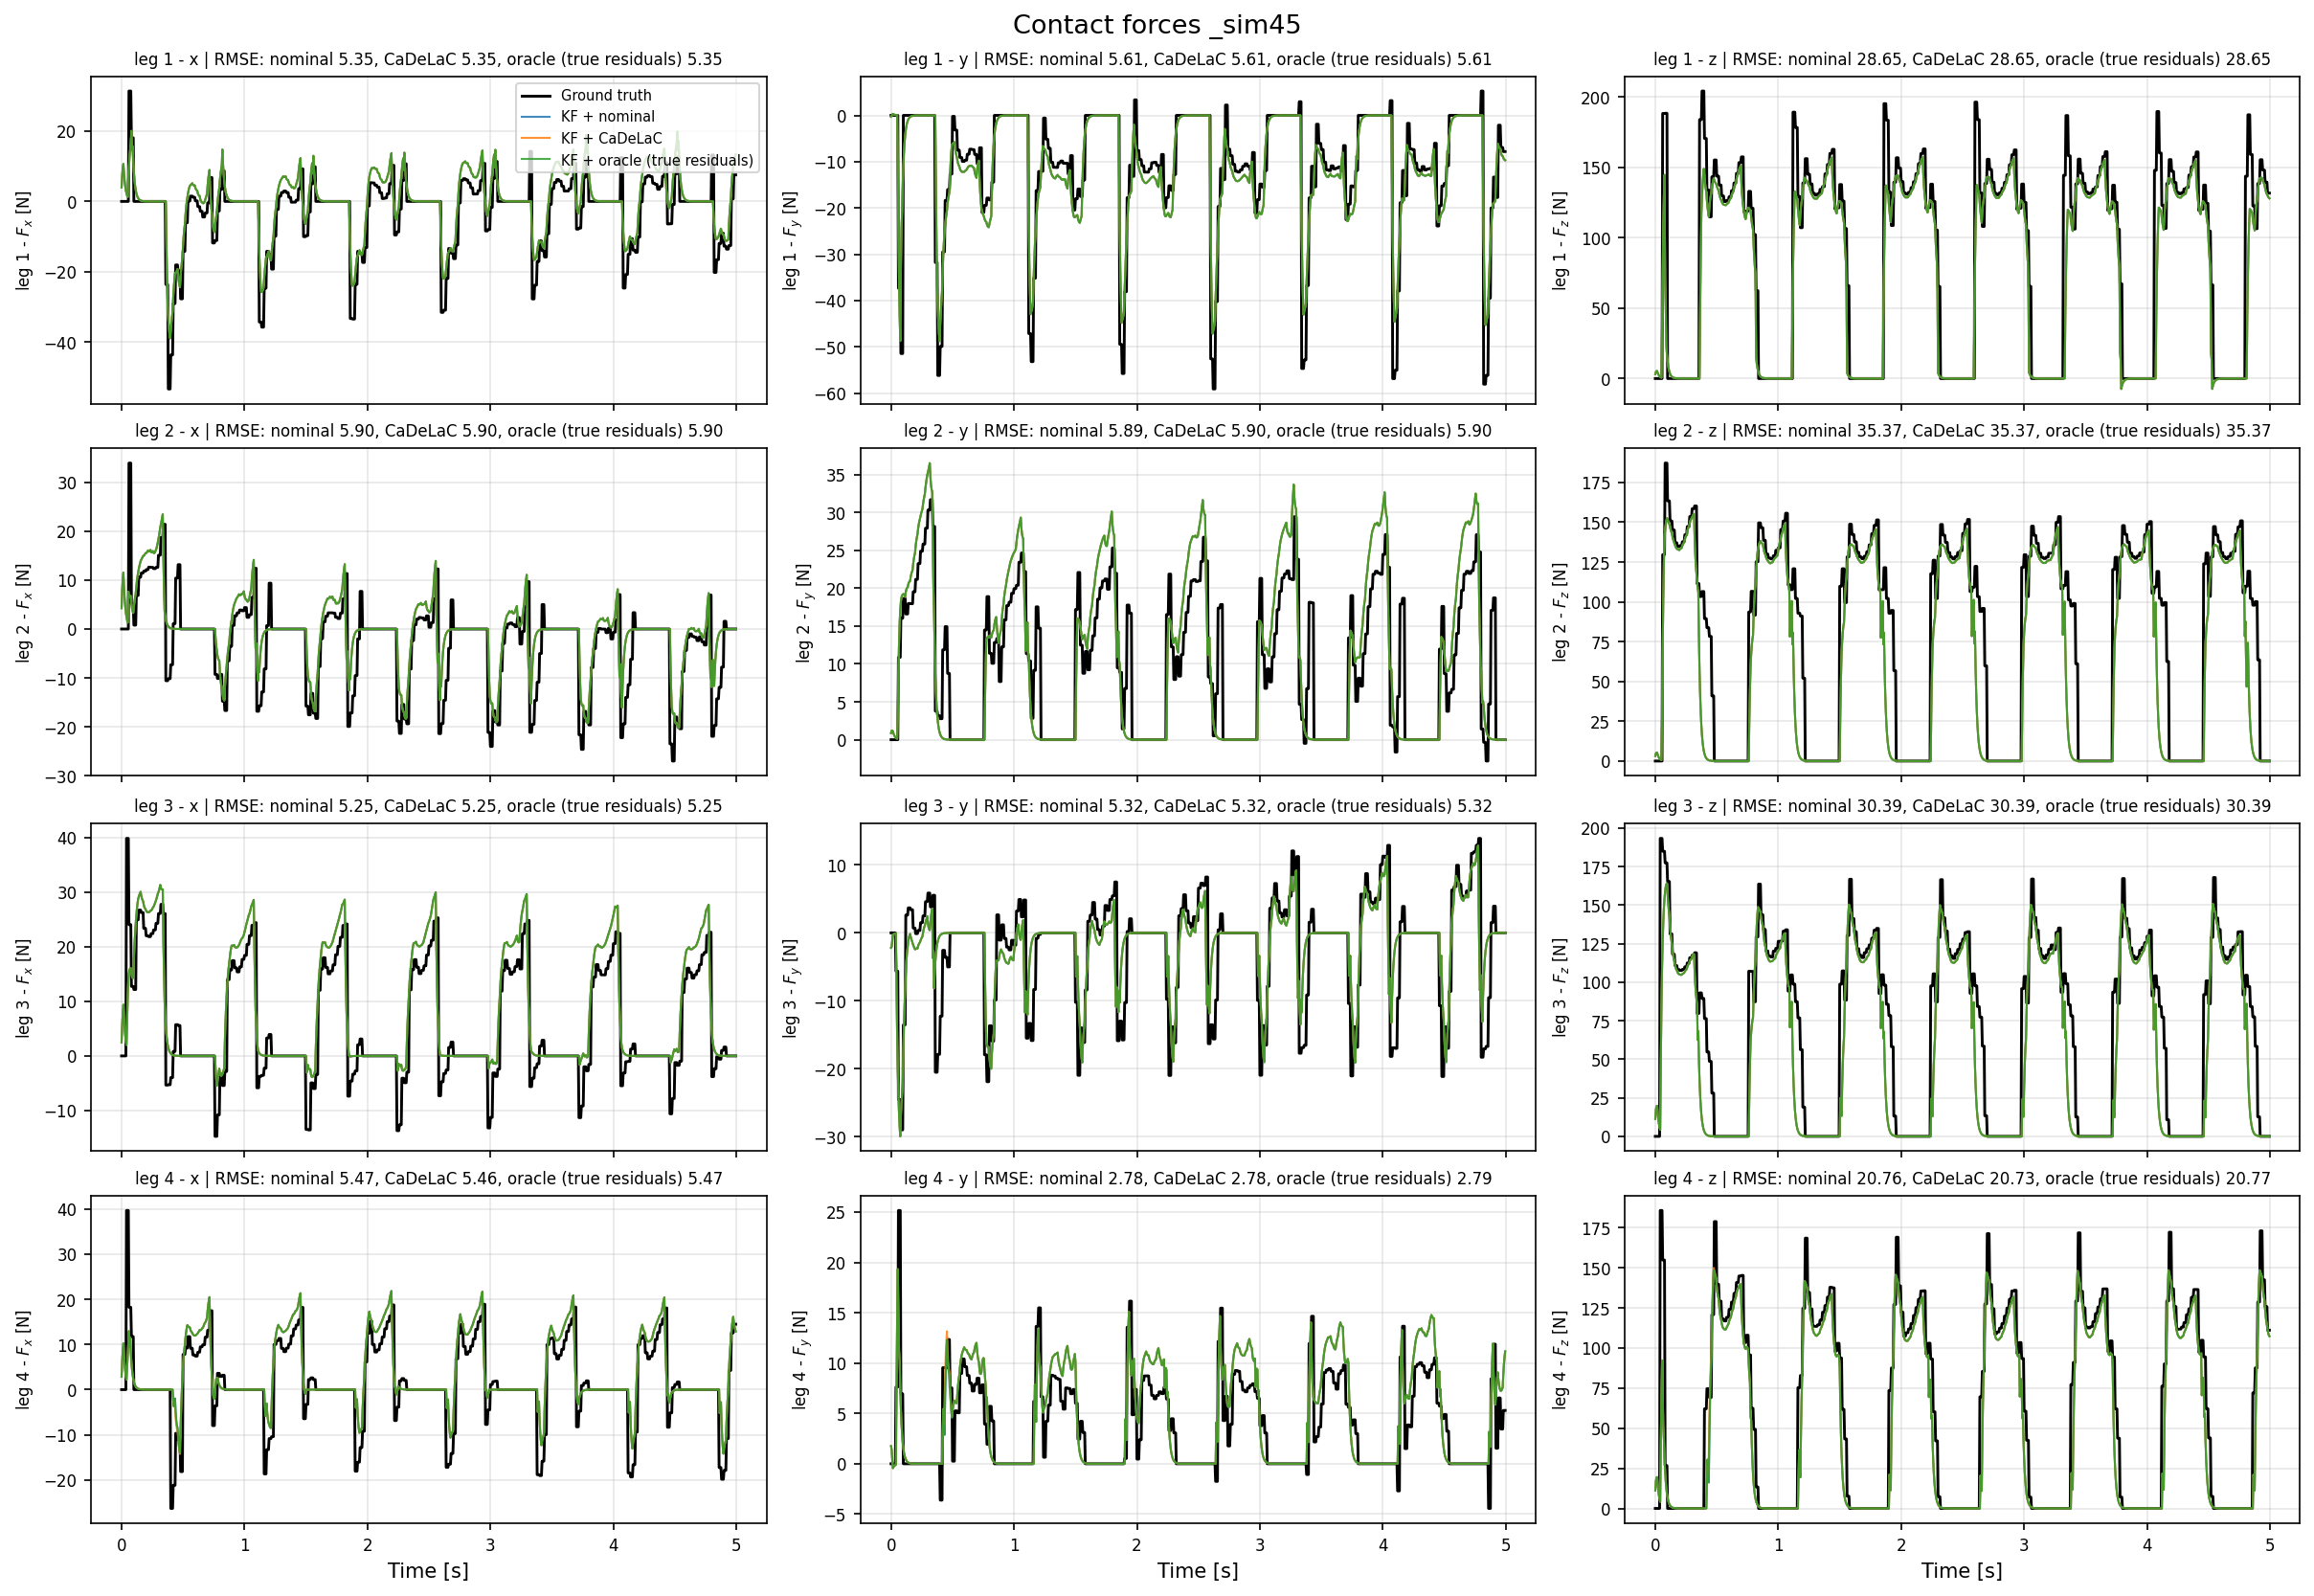

In [6]:
from utils.report_plots import plot_state_comparison
import numpy as np

# Pro Zustandsparameter eine Figur (lin vel: 5 Kurven inkl. Leg-Odom; sonst 4).
# Alle Figuren werden zusaetzlich als PNG+PDF unter figures/report_part2/ gespeichert.
figs = plot_state_comparison(data, ladder, sim_label=f"_sim{sim_num}",
                             save_dir=fig_dir / "state_plots")

# RMSE-Zusammenfassung dieses Laufs (gleiche Groessen wie in den Plots)
gt_v, gt_w = data["base_vel"], data["base_ang_vel"]
print(f"{'Methode':<16}{'vel x':>8}{'vel y':>8}{'vel z':>8}   {'ang vel (Mittel)':>16}")
lo = np.sqrt(np.mean((np.asarray(next(iter(ladder.values()))["leg_odom_vel"]) - gt_v) ** 2, axis=0))
print(f"{'Leg-Odom':<16}{lo[0]:>8.3f}{lo[1]:>8.3f}{lo[2]:>8.3f}   {'-':>16}")
for v, r in ladder.items():
    ve = np.sqrt(np.mean((np.asarray(r["vel_update"]) - gt_v) ** 2, axis=0))
    we = float(np.mean(np.sqrt(np.mean((np.asarray(r["ang_vel_update"]) - gt_w) ** 2, axis=0))))
    print(f"{v:<16}{ve[0]:>8.3f}{ve[1]:>8.3f}{ve[2]:>8.3f}   {we:>16.3f}")